# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

In [40]:
import random
import matplotlib.pyplot as plt

1. Begin by creating a classes to represent cards and decks. The deck should support more than one 52-card set. The deck should allow you to shuffle and draw cards. Include a "plastic" card, placed randomly in the deck. Later, when the plastic card is dealt, shuffle the cards before the next deal.

In [41]:
class Card:
    def __init__(self, suit, rank):
        #Each card has a suit and rank
        self.suit = suit
        self.rank = rank

    def value(self):
        """
        Returns blackjack value of card
        Ace is returned as 11 here, the Hand class will adjust it down to 1 if the total would bust.
        """
        if self.rank in ['Jack', 'Queen', 'King']:
            return 10
        elif self.rank == 'Ace':
            return 11  # we adjust later if needed
        else:
            return int(self.rank)

    def count_value(self):
        """
        This is for card counting strategy
        """
        if self.rank in ['2', '3', '4', '5', '6']:
            return 1
        elif self.rank in ['7', '8', '9']:
            return 0
        else:
            return -1

    def __str__(self):
        """
        Asked Chatgpt how to print(card) and get something readable instead of something like <Card object at 0x...> 
        """
        return f"{self.rank} of {self.suit}"
    

In [42]:
class Deck:
    def __init__(self, num_decks=6):   # we use 6 decks by default since that is standard casino play
        self.num_decks = num_decks
        self.cards = []

        self.create_deck()
        self.shuffle()

        # plastic card position
        self.plastic_position = random.randint(0, len(self.cards))

    def create_deck(self):
        suits = ['Hearts', 'Diamonds', 'Clubs', 'Spades']
        ranks = ['2', '3', '4', '5', '6', '7', '8', '9', '10',
                 'Jack', 'Queen', 'King', 'Ace']

        for _ in range(self.num_decks):
            for suit in suits:
                for rank in ranks:
                    self.cards.append(Card(suit, rank))

    def shuffle(self):
        random.shuffle(self.cards) # Shuffles the whole shoe randomly

    def draw_card(self):
        if len(self.cards) == 0:
            self.create_deck()
            self.shuffle()

        card = self.cards.pop()

        # Check plastic card (When the plastic card is dealt, we reshuffle before the next round)
        if len(self.cards) == self.plastic_position:
            print("Plastic card reached! We will reshuffle.")

        return card

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 


Solution pdf uploaded separately.

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

### My Classes 

**1. Card**
- Attributes:
  - suit
  - rank
- Methods:
  - value(): returns blackjack value of the card
  - count_value(): returns value used for card counting
  - __str__(): string representation of the card

**2. Deck**
- Attributes:
  - cards (list of Card objects)
  - number of decks
  - plastic card position
- Methods:
  - create_deck(): generates cards
  - shuffle(): shuffles deck
  - draw_card(): removes and returns a card

**3. Hand**
- Attributes:
  - cards (list of cards in hand)
- Methods:
  - add_card(): adds a card to hand
  - total(): computes total value of hand
  - show(): displays cards

**4. Player**
- Attributes:
  - name
  - chips
  - hand
- Methods:
  - hit(): draw a card
  - play(): defines player behavior
  - reset_hand(): clears hand for new round

**5. Dealer (inherits from Player)**
- Methods:
  - play(): follows fixed rule (hit until 16)

**6. StrategyPlayer (inherits from Player)**
- Attributes:
  - running_count
  - threshold
- Methods:
  - update_count(): updates card count
  - play(): uses strategy to decide hit or stay

**7. Game**
- Attributes:
  - deck
  - players
  - dealer
- Methods:
  - deal_initial(): deals starting cards
  - play_round(): runs one round of blackjack
  - play_game(): runs multiple rounds


4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [43]:
class Hand:
    def __init__(self):
        self.cards = []

    def add_card(self, card):
        self.cards.append(card)

    def total(self):
        """
        Computes total value of hand
        Handles Ace (1 or 11)
        """
        total = sum(card.value() for card in self.cards)
        aces = sum(1 for card in self.cards if card.rank == 'A')

        # adjust Aces if total > 21
        while total > 21 and aces > 0:
            total -= 10
            aces -= 1

        return total

    def show(self):
        for card in self.cards:
            print(card)

In [44]:
class Player:
    def __init__(self, name, chips=100):
        self.name = name
        self.chips = chips
        self.hand = Hand()

    def hit(self, deck):
        # draw a card and add to hand
        self.hand.add_card(deck.draw_card())

    def play(self, deck):#strategy: hit until 16
        while self.hand.total() < 16:
            self.hit(deck)

    def reset_hand(self):
        self.hand = Hand()

In [45]:
class Dealer(Player):
    def play(self, deck):#Dealer must hit until 16
        while self.hand.total() < 16:
            self.hit(deck)

In [59]:
class StrategyPlayer(Player):
    def __init__(self, name, threshold=0, chips=100):
        super().__init__(name, chips)
        self.running_count = 0
        self.threshold = threshold

    def update_count(self, card):
        self.running_count += card.count_value()

    def play(self, deck):
        """
        Strategy:
        - if count is negative: HIT
        - if count is positive: STAY
        """
        while self.hand.total() < 21:
            if self.running_count < self.threshold:
                self.hit(deck)
            else:
                break
                

Explanation:

The player keeps track of a running count based on the cards seen:
- Low cards increase the count
- High cards decrease the count

Based on this running count and a chosen threshold:
- The player hits when the count is low (more high cards expected)
- The player stays when the count is high

In [47]:
class Game:
    def __init__(self, num_players=3, threshold=0, verbose=False):
        self.deck = Deck()
        self.verbose = verbose

        # players
        self.players = [Player(f"P{i}") for i in range(num_players)]
        self.strategy_player = StrategyPlayer("Strategy", threshold)
        self.dealer = Dealer("Dealer")

        self.all_players = self.players + [self.strategy_player]

    def deal_initial(self): #Dealing initial cards
        for player in self.all_players + [self.dealer]:
            player.reset_hand()
            player.hit(self.deck)
            player.hit(self.deck)

    def play_round(self):
        self.deal_initial()

        # players play
        for player in self.all_players:
            player.play(self.deck)

        # dealer plays
        self.dealer.play(self.deck)

        dealer_total = self.dealer.hand.total()

        # evaluate results
        for player in self.all_players:
            player_total = player.hand.total()

            if player_total > 21:
                player.chips -= 1
            elif dealer_total > 21 or player_total > dealer_total:
                player.chips += 1
            elif player_total < dealer_total:
                player.chips -= 1
            # tie = no change

    def play_game(self, rounds=50):
        for _ in range(rounds):
            if self.strategy_player.chips <= 0:
                break
            self.play_round()

        return self.strategy_player.chips

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

## Q5: Testing Game Play
We simulate one game to verify functionality.

In [48]:
game = Game(num_players=3, threshold=0)
result = game.play_game(rounds=50)

print("Strategy player final chips:", result)

Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Strategy player final chips: 91


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

## Strategy Player Class does this card counting

In this part, we implement a player that uses a simple card counting strategy to make decisions.

Each card is assigned a value:
- Cards 2 through 6 are assigned +1
- Cards 7 through 9 are assigned 0
- Cards 10 through Ace are assigned -1

The player keeps a running count by adding these values for every card seen during the game.

### Strategy Logic
- If the running count is very negative, it means more high-value cards are likely remaining in the deck, so the player chooses to hit
- If the running count is positive, it means more low-value cards remain, so the player chooses to stay

We introduce a threshold value (e.g., 0 or -2) to decide when to hit or stay:
- If running count < threshold then HIT
- Otherwise then STAY

This strategy allows the player to make more informed decisions

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [49]:
#Q7: Single Game Simulation (50 rounds)
game = Game(num_players=3, threshold=0)
result = game.play_game(rounds=50)

print("Strategy player final chips:", result)

Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Strategy player final chips: 103


8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


In [50]:
#Statistical Analysis
#We run 100 simulations and analyze results.
results = []

for _ in range(100):
    game = Game(num_players=3, threshold=0)
    final_chips = game.play_game(50)
    results.append(final_chips)

Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card rea

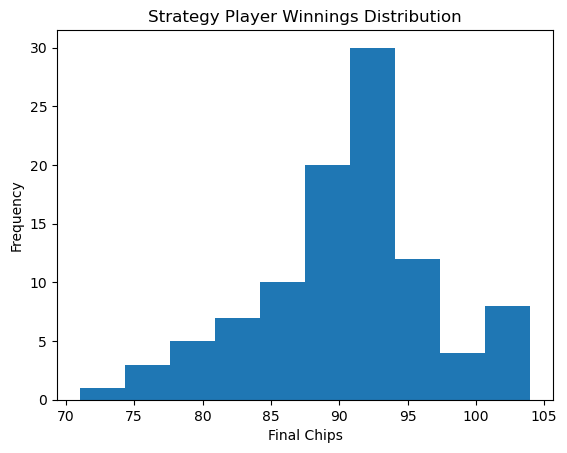

In [51]:
plt.hist(results)
plt.title("Strategy Player Winnings Distribution")
plt.xlabel("Final Chips")
plt.ylabel("Frequency")
plt.show()

In [52]:
import statistics

avg = statistics.mean(results)
std = statistics.stdev(results)

wins = sum(1 for r in results if r > 100)
losses = sum(1 for r in results if r < 100)

print("Average:", avg)
print("Std Dev:", std)
print("Win Probability:", wins / len(results))
print("Loss Probability:", losses / len(results))

Average: 90.5
Std Dev: 6.627917691801319
Win Probability: 0.08
Loss Probability: 0.92


9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

In [53]:
#Threshold Optimization
thresholds = [-3, -2, 0, 2, 3]
avg_results = []

for t in thresholds:
    results = []
    for _ in range(50):
        game = Game(num_players=3, threshold=t)
        results.append(game.play_game(50))
    avg_results.append(sum(results)/len(results))

print("Threshold vs Average:")
for t, avg in zip(thresholds, avg_results):
    print(t, ":", avg)

Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card rea

Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card rea

Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card reached! We will reshuffle.
Plastic card rea

10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [58]:
# Q10: New Strategy Implementation
class New_Strat_Player(StrategyPlayer):
    def play(self, deck):
        """
        This is more cautious since we stop at 14 if count positive
        """
        while self.hand.total() < 21:
            if self.running_count < self.threshold:
                self.hit(deck)
            elif self.hand.total() < 14:
                self.hit(deck)
            else:
                break
                

Explanation:

In this part, we implement a modified strategy that is more conservative.  

This player:
- Still uses card counting
- But avoids taking risks when their hand value is already reasonably high